In [126]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader
import logging
import sys
import io

# --- 로거 설정 (디버깅용) ---
logger = logging.getLogger("vanilla_vq_logger")
logger.setLevel(logging.INFO)
logger.handlers = [] # 핸들러 초기화

stdout_handler = logging.StreamHandler(sys.stdout)
stdout_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
logger.addHandler(stdout_handler)

print("Imports and Logger initialized.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Imports and Logger initialized.
PyTorch version: 2.1.0+cu121
CUDA available: True


In [135]:
class VanillaVQVAE(nn.Module):
    """
    [수정됨] Headless 버전 (Prediction Head 없음)
    - nn.Linear조차 없음.
    - 코드북 벡터(z_q) 자체가 곧바로 Class Score(Logits)가 됨.
    - 따라서 embedding_dim_D는 반드시 num_classes (10)와 같아야 함.
    """
    def __init__(self, input_dim, num_codes_K, embedding_dim_D, beta, num_classes):
        super().__init__()
        
        self.K = num_codes_K
        self.D = embedding_dim_D
        self.beta = beta
        self.num_classes = num_classes

        # ❗️ [검증] Head가 없으므로 차원이 맞아야 함
        if self.num_classes == 2:
            # 이진 분류면 D=1 이어야 함
            if self.D != 1:
                print(f"⚠️ WARNING: Headless Binary Model needs D=1, but got D={self.D}")
        else:
            # 다중 분류면 D=num_classes 이어야 함
            if self.D != self.num_classes:
                print(f"⚠️ WARNING: Headless Model needs D={self.num_classes}, but got D={self.D}")

        # 1. 인코더
        self.encoder = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(input_dim, input_dim // 2),
            nn.ReLU(),
            nn.Linear(input_dim // 2, self.D) 
        )

        # 2. 코드북
        self.codebook = nn.Embedding(self.K, self.D)
        nn.init.xavier_uniform_(self.codebook.weight)

        # ❗️ [제거] prediction_head 없음
        
        logger.info(f"VanillaVQVAE (Headless) initialized: K={self.K}, D={self.D}")

    def forward(self, x_in, y_true):
        
        # 1. 인코딩
        z_e = self.encoder(x_in) # [B, D]
        
        B, D = z_e.shape
        codebook_vectors = self.codebook.weight 

        # --- 2. Quantization (Q) ---
        distances_sq = torch.sum((z_e.unsqueeze(1) - codebook_vectors.unsqueeze(0))**2, dim=2)
        indices = torch.argmin(distances_sq, dim=1) 
        z_q = self.codebook(indices) 

        # --- 3. Straight-Through Estimator (STE) ---
        z_q_ste = z_e + (z_q - z_e).detach()
        
        # --- 4. 손실(Loss) 계산 ---
        
        # ❗️ [수정] Head 없이 벡터 자체를 Logit으로 사용
        logits = z_q_ste # [B, D] (D=10 이어야 함)
        
        if self.num_classes == 2:
             # 이진 분류 (D=1)
            loss_ce = F.binary_cross_entropy_with_logits(logits.squeeze(1), y_true.float())
        else:
            # 다중 분류 (D=10)
            loss_ce = F.cross_entropy(logits, y_true)
        
        # (Loss 2) VQ Loss
        loss_v = F.mse_loss(z_q, z_e.detach())
        loss_q = F.mse_loss(z_e, z_q.detach())
        
        # --- 5. 최종 손실 ---
        total_loss = loss_ce + loss_v + (self.beta * loss_q)
        
        return total_loss, logits, indices, loss_ce, loss_v, loss_q

print("VanillaVQVAE class (Headless / Direct Codebook Prediction) defined.")

VanillaVQVAE class (Headless / Direct Codebook Prediction) defined.


In [136]:
# --- 하이퍼파라미터 ---
BATCH_SIZE = 128
D_DIM = 768      # GAT [CLS] 토큰의 차원 (D)
K_CODES = 64    # VQ 코드북 크기 (K)
BETA = 0.25     # VQ Commitment 가중치
LEARNING_RATE = 1e-3
N_STEPS = 3000

# --- MNIST Data ---
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
    # ❗️ transforms.Flatten() 제거됨
])

# 훈련 데이터 로더
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# 테스트 데이터 (PCA 시각화용)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

# 입력 차원 (784)과 클래스 수 (10)
INPUT_DIM = 784
NUM_CLASSES = 10

logger.info(f"MNIST Data Loaded: Input Dim={INPUT_DIM}, Classes={NUM_CLASSES}")

2025-11-17 13:06:06,308 - INFO - MNIST Data Loaded: Input Dim=784, Classes=10


In [137]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

# ❗️ (수정) input_dim과 num_classes 인자 추가
model = VanillaVQVAE(
    input_dim=INPUT_DIM,       # ❗️ (추가)
    num_codes_K=K_CODES,
    embedding_dim_D=D_DIM,
    beta=BETA,
    num_classes=NUM_CLASSES    # ❗️ (추가)
).to(device)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- 모니터링용 변수 ---
history = {
    'total_loss': [],
    'loss_ce': [],
    'loss_v': [],
    'loss_q': [],
    'accuracy': [], 
    'codebook_usage_pct': [],
    'z_e_l2': [], # ❗️ [수정] L2 Norm 저장용
    'fy_l2': []   # ❗️ [수정] L2 Norm 저장용
}

# --- 학습 루프 ---
train_iter = iter(train_loader)

for step in range(N_STEPS):
    try:
        batch_x, batch_y = next(train_iter)
    except StopIteration:
        train_iter = iter(train_loader)
        batch_x, batch_y = next(train_iter)
        
    batch_x = batch_x.to(device) # [B, 1, 28, 28]
    batch_y = batch_y.to(device) # [B]
    
    # --- ❗️ [수정] z_e를 로깅하기 위해 forward 전에 encoder만 따로 호출 ---
    with torch.no_grad():
        # (encoder는 nn.Flatten()으로 시작하므로 [B, 1, 28, 28] 입력)
        z_e_for_log = model.encoder(batch_x)
    # --- [수정 끝] ---
    
    # (x_in은 [B, 1, 28, 28]을 받아 forward 내부의 encoder가 [B, 784]로 바꿈)
    total_loss, logits, code_indices, loss_ce, loss_v, loss_q = model(batch_x, batch_y)
    
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()
    
    # --- 로깅 ---
    if step % 100 == 0 or step == N_STEPS - 1:
        with torch.no_grad():
            preds = torch.argmax(logits, dim=1)
            acc = (preds == batch_y).float().mean()
        
        usage_pct = len(torch.unique(code_indices)) / K_CODES * 100
        
        # --- [ ❗️❗️ 새로운 통계 로깅 ❗️❗️ ] ---
        with torch.no_grad():
            # 1. z_e ([CLS] token) stats (z_e_for_log 사용)
            z_e_mean = z_e_for_log.mean().item()
            z_e_std = z_e_for_log.std().item()
            z_e_l2_sq = (z_e_for_log**2).sum(-1).mean().item()
            
            # 2. Codebook (Fy) stats (전체 코드북 기준)
            codebook_vectors = model.codebook.weight
            fy_mean = codebook_vectors.mean().item()
            fy_std = codebook_vectors.std().item()
            fy_l2_sq = (codebook_vectors**2).sum(-1).mean().item()
        
        logger.info("--- 📊 VQ Inputs (Stats) ---")
        logger.info(f"  [z_e (Encoder)] mean: {z_e_mean:.4f}, std: {z_e_std:.4f}, L2_norm_sq: {z_e_l2_sq:.4f}")
        logger.info(f"  [Codebook]      mean: {fy_mean:.4f}, std: {fy_std:.4f}, L2_norm_sq: {fy_l2_sq:.4f}")
        # --- [ 로깅 끝 ] ---

        logger.info(
            f"[Step {step:4d}/{N_STEPS}] "
            f"Total Loss: {total_loss.item():.4f} | "
            f"Accuracy: {acc:.4f} | "
            f"Codebook Usage: {usage_pct:3.0f}% ({len(torch.unique(code_indices))}/{K_CODES})"
        )
        
        history['total_loss'].append(total_loss.item())
        history['loss_ce'].append(loss_ce.item())
        history['loss_v'].append(loss_v.item())
        history['loss_q'].append(loss_q.item())
        history['accuracy'].append(acc.item())
        history['codebook_usage_pct'].append(usage_pct)
        history['z_e_l2'].append(z_e_l2_sq) # ❗️ (저장)
        history['fy_l2'].append(fy_l2_sq)   # ❗️ (저장)

logger.info("--- 훈련 완료 ---")

2025-11-17 13:06:07,341 - INFO - Using device: cuda


⚠️ WARNING: Headless Model needs D=10, but got D=768
2025-11-17 13:06:07,357 - INFO - VanillaVQVAE (Headless) initialized: K=64, D=768
2025-11-17 13:06:07,423 - INFO - --- 📊 VQ Inputs (Stats) ---
2025-11-17 13:06:07,425 - INFO -   [z_e (Encoder)] mean: -0.0071, std: 0.2454, L2_norm_sq: 46.2700
2025-11-17 13:06:07,426 - INFO -   [Codebook]      mean: 0.0001, std: 0.0491, L2_norm_sq: 1.8483
2025-11-17 13:06:07,428 - INFO - [Step    0/3000] Total Loss: 6.7027 | Accuracy: 0.0000 | Codebook Usage:  31% (20/64)
2025-11-17 13:06:09,227 - INFO - --- 📊 VQ Inputs (Stats) ---
2025-11-17 13:06:09,228 - INFO -   [z_e (Encoder)] mean: -0.1277, std: 19.3905, L2_norm_sq: 288772.5000
2025-11-17 13:06:09,229 - INFO -   [Codebook]      mean: -0.0029, std: 0.0508, L2_norm_sq: 1.9848
2025-11-17 13:06:09,231 - INFO - [Step  100/3000] Total Loss: 475.3002 | Accuracy: 0.0938 | Codebook Usage:   2% (1/64)
2025-11-17 13:06:11,123 - INFO - --- 📊 VQ Inputs (Stats) ---
2025-11-17 13:06:11,124 - INFO -   [z_e (Enco

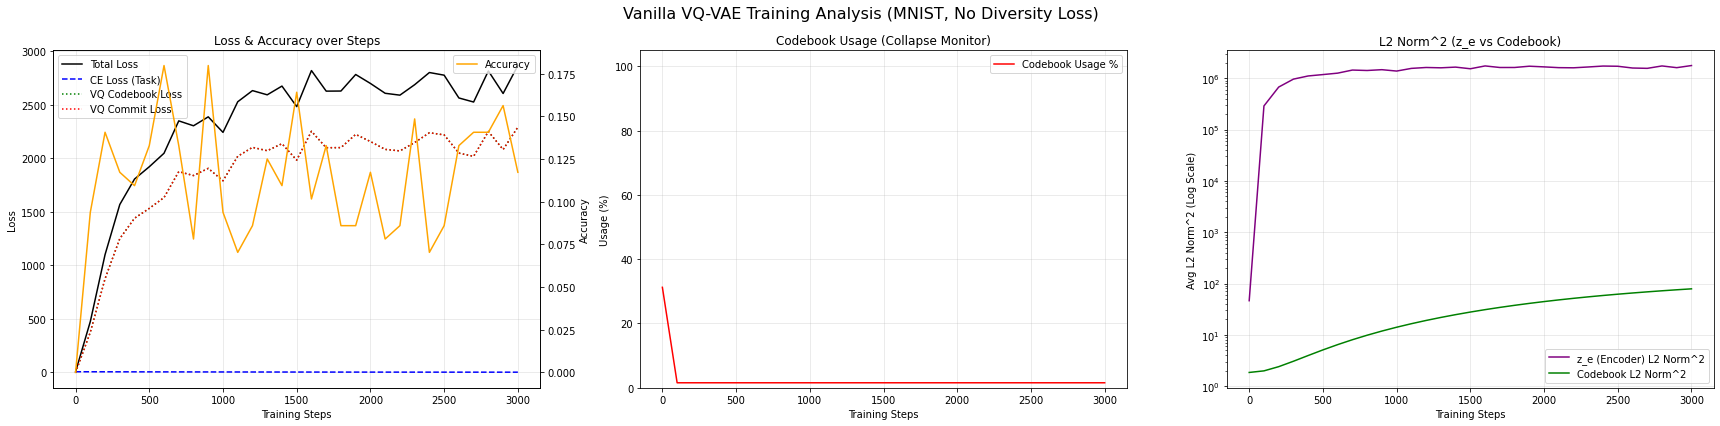

2025-11-17 13:07:11,958 - INFO - Visualizing final embedding space (using Test Set)...


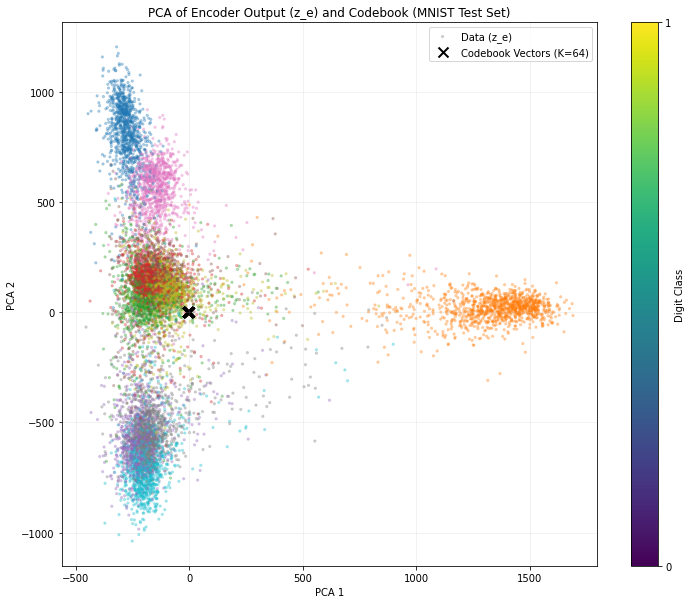

In [138]:
#
# ❗️ (블럭 5) 덮어쓰기
#
# --- 1. 훈련 곡선 시각화 (❗️ 1x3 그리드로 변경) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6)) # ❗️ (1x3)
steps = np.arange(len(history['total_loss'])) * 100

# (a) 손실 및 Accuracy
ax1.plot(steps, history['total_loss'], label='Total Loss', color='black', linestyle='-')
ax1.plot(steps, history['loss_ce'], label='CE Loss (Task)', color='blue', linestyle='--')
ax1.plot(steps, history['loss_v'], label='VQ Codebook Loss', color='green', linestyle=':')
ax1.plot(steps, history['loss_q'], label='VQ Commit Loss', color='red', linestyle=':')
ax1_twin = ax1.twinx()
ax1_twin.plot(steps, history['accuracy'], label='Accuracy', color='orange', linestyle='-') 
ax1.set_title("Loss & Accuracy over Steps")
ax1.set_xlabel("Training Steps")
ax1.set_ylabel("Loss")
ax1_twin.set_ylabel("Accuracy")
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# (b) 코드북 붕괴(Collapse)
ax2.plot(steps, history['codebook_usage_pct'], label='Codebook Usage %', color='red')
ax2.set_title("Codebook Usage (Collapse Monitor)")
ax2.set_xlabel("Training Steps")
ax2.set_ylabel("Usage (%)")
ax2.set_ylim(0, 105)
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- [ ❗️ (c) 신규: L2 Norm^2 스케일 플롯 ❗️ ] ---
ax3.plot(steps, history['z_e_l2'], label='z_e (Encoder) L2 Norm^2', color='purple')
ax3.plot(steps, history['fy_l2'], label='Codebook L2 Norm^2', color='green')
ax3.set_title("L2 Norm^2 (z_e vs Codebook)")
ax3.set_xlabel("Training Steps")
ax3.set_ylabel("Avg L2 Norm^2 (Log Scale)")
ax3.set_yscale('log') # ❗️ (로그 스케일)
ax3.legend()
ax3.grid(True, alpha=0.3)
# --- [ 신규 플롯 끝 ] ---

plt.suptitle("Vanilla VQ-VAE Training Analysis (MNIST, No Diversity Loss)", fontsize=16)
plt.tight_layout()
plt.show()


# --- 2. PCA 임베딩 공간 (클러스터링) 시각화 ---
logger.info("Visualizing final embedding space (using Test Set)...")

# (a) 테스트셋 전체에서 z_e (잠재 벡터)와 레이블 수집
all_z_e = []
all_y = []
model.eval()
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        z_e = model.encoder(batch_x) # [B, D_DIM]
        
        all_z_e.append(z_e.cpu().numpy())
        all_y.append(batch_y.cpu().numpy())

Z_e_np = np.concatenate(all_z_e, axis=0) # [10000, D_DIM]
y_np = np.concatenate(all_y, axis=0) # [10000]
codebook_vectors_np = model.codebook.weight.detach().cpu().numpy() # [K, D_DIM]

# (b) PCA (인코더 출력 z_e 기준)
pca = PCA(n_components=2)
Z_e_2d = pca.fit_transform(Z_e_np) # 원본 z_e를 2D로
codebook_2d = pca.transform(codebook_vectors_np) # 코드북을 *동일한* 2D 공간으로

# (c) 플로팅 (데이터와 코드북 클러스터링)
plt.figure(figsize=(12, 10))
plt.scatter(Z_e_2d[:, 0], Z_e_2d[:, 1], c=y_np, cmap='tab10', alpha=0.3, s=5, label='Data (z_e)')
plt.scatter(codebook_2d[:, 0], codebook_2d[:, 1], 
            marker='x', s=100, color='black', linewidth=2, 
            label=f'Codebook Vectors (K={K_CODES})')

plt.title("PCA of Encoder Output (z_e) and Codebook (MNIST Test Set)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.colorbar(ticks=range(10), label="Digit Class")
plt.grid(True, alpha=0.2)
plt.show()

### 2. BasisGAT + VQVAE

In [139]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
import logging
import sys
import io
from pathlib import Path
import pickle 
from sklearn.model_selection import train_test_split 
import random 
import os 
import math 
from torch import Tensor 

# --- (필수) 프로젝트 경로 설정 ---
PROJECT_ROOT = "/home/eungyeop/LLM/tabular/ProtoLLM" # ❗️ (경로 확인)
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from utils.util import fix_seed
from dataset.data_dataloaders import prepare_embedding_dataloaders
# ❗️ [수정] Model 대신 BasisGATLayer 임포트
from models.BasisGraphAttention import BasisGATLayer_MUL, BasisGATLayer_IND 
from argparse import Namespace
# ----------------------------------------

# --- 로거 설정 ---
logger = logging.getLogger("step2_vq_logger")
# ... (이하 로거 설정 동일) ...

print("Imports and Logger initialized.")

Imports and Logger initialized.


In [140]:
#
# ❗️ (블럭 2) 덮어쓰기
#
class GAT_Encoder(nn.Module):
    """
    Model.predict()에서 GAT 스택 부분만 추출한 인코더.
    batch (dict)를 받아 [CLS] 토큰을 반환합니다.
    """
    def __init__(self, args):
        super().__init__()
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.args = args
        self.input_dim = args.input_dim
        self.hidden_dim = args.hidden_dim
        self.num_basis_layers = args.num_basis_layers
        self.dropout_rate = args.dropout_rate
        
        # CLS 토큰
        self.basis_cls = nn.Parameter(Tensor(1, 1, self.input_dim))
        nn.init.uniform_(self.basis_cls, a=-1/math.sqrt(self.input_dim), b=1/math.sqrt(self.input_dim))
        
        # GAT 레이어 (args.basis_type에 따라 분기)
        if args.basis_type == 'mul':
            self.basis_layers = nn.ModuleList([ 
                BasisGATLayer_MUL(args, input_dim = self.input_dim, hidden_dim = self.hidden_dim, num_basis_heads = args.num_basis_heads, dropout = self.dropout_rate)
                for _ in range(self.num_basis_layers)
            ])
        elif args.basis_type == 'ind':
            self.basis_layers = nn.ModuleList([ 
                BasisGATLayer_IND(args, input_dim = self.input_dim, hidden_dim = self.hidden_dim, num_basis_heads = args.num_basis_heads, dropout = self.dropout_rate)
                for _ in range(self.num_basis_layers)
            ])
        self.basis_layer_norms = nn.ModuleList([ 
            nn.LayerNorm(self.input_dim) for _ in range(self.num_basis_layers)
        ])
        
        self.x_basis = None # (디버깅용)

    def forward(self, batch):
        # ❗️ [수정] Model.predict()의 "gather" 로직을 그대로 복사
        desc_embeddings, name_embeddings, value_embeddings = [], [], []
        
        if all(k in batch for k in ['cat_name_embeddings', 'cat_value_embeddings', 'cat_desc_embeddings']):
            desc_embeddings.append(batch['cat_desc_embeddings'].to(self.device))
            name_embeddings.append(batch['cat_name_embeddings'].to(self.device))
            value_embeddings.append(batch['cat_value_embeddings'].to(self.device))
        if all(k in batch for k in ['num_prompt_embeddings', 'num_desc_embeddings', 'num_name_embeddings']):
            desc_embeddings.append(batch['num_desc_embeddings'].to(self.device))
            name_embeddings.append(batch['num_name_embeddings'].to(self.device))
            value_embeddings.append(batch['num_prompt_embeddings'].to(self.device))
        
        if not desc_embeddings or not name_embeddings or not value_embeddings:
             raise ValueError("No categorical or numerical features found in batch (e.g., 'cat_name_embeddings' or 'num_prompt_embeddings')")

        desc = torch.cat(desc_embeddings, dim = 1)
        name = torch.cat(name_embeddings, dim = 1)
        value = torch.cat(value_embeddings, dim = 1)
        # --- [Gather 로직 끝] ---
        x_basis = torch.cat([self.basis_cls.expand(value.size(0), 1, self.input_dim), value], dim=1)
        last_att = None
        # --- [ ❗️ Post-Norm으로 수정된 루프 ❗️ ] ---
        for l in range(self.num_basis_layers):
            # 1. Layer (Norm을 먼저 적용하지 않음)
            basis_outputs, att = self.basis_layers[l](name, x_basis) 
            
            # 2. Residual Add
            x_basis = x_basis + basis_outputs.reshape(x_basis.size(0), x_basis.size(1), self.input_dim)
            
            # 3. Norm (마지막에 적용)
            x_basis = self.basis_layer_norms[l](x_basis) 
            
            last_att = att
        
        self.x_basis = x_basis
        
        # [CLS] 토큰 추출
        z_e_cls = x_basis[:, 0, :] # [B, D_full]
        
        return z_e_cls

# -----------------------------------------------------------------

class VanillaVQVAE(nn.Module):
    """
    GAT의 [CLS] 토큰 (z_e)을 입력받아 VQ + 분류 수행
    (Local Pred Bypass 없음)
    """
    def __init__(self, num_codes_K, embedding_dim_D, beta, num_classes):
        super().__init__()
        
        self.K = num_codes_K
        self.D = embedding_dim_D
        self.beta = beta
        self.num_classes = num_classes

        # 1. 코드북
        self.codebook = nn.Embedding(self.K, self.D)
        nn.init.xavier_uniform_(self.codebook.weight)

        # 2. "디코더" (분류기)
        output_dim = 1 if num_classes == 2 else num_classes
        self.prediction_head = nn.Sequential(
            nn.Linear(self.D, self.D // 2),
            nn.ReLU(),
            nn.Linear(self.D // 2, output_dim)
        )
        
        logger.info(f"VanillaVQVAE initialized: K={self.K}, D={self.D}")

    def forward(self, z_e, y_true):
        B, D = z_e.shape
        codebook_vectors = self.codebook.weight 

        # 1. Quantization (Q)
        distances_sq = torch.sum((z_e.unsqueeze(1) - codebook_vectors.unsqueeze(0))**2, dim=2)
        indices = torch.argmin(distances_sq, dim=1)
        z_q = self.codebook(indices)

        # 2. STE
        z_q_ste = z_e + (z_q - z_e).detach()
        
        # 3. 손실(Loss)
        logits = self.prediction_head(z_q_ste) # ❗️ VQ 벡터로만 예측
        
        if self.num_classes == 2:
            loss_task = F.binary_cross_entropy_with_logits(logits.squeeze(1), y_true.float().squeeze(1)) # BCE
        else:
            loss_task = F.cross_entropy(logits, y_true.long()) # CE

        loss_v = F.mse_loss(z_q, z_e.detach())
        loss_q = F.mse_loss(z_e, z_q.detach())
        
        total_loss = loss_task + loss_v + (self.beta * loss_q)
        
        return total_loss, logits, indices, loss_task, loss_v, loss_q

print("GAT_Encoder (with Model.predict logic) and VanillaVQVAE classes defined (BCE loss fixed).")

GAT_Encoder (with Model.predict logic) and VanillaVQVAE classes defined (BCE loss fixed).


In [141]:
#
# ❗️ (블럭 3) 덮어쓰기
#
# --- 1. 하이퍼파라미터 ---
D_FULL = 768    # GAT의 input_dim (get_args() 기본값 768)
N_BASIS_HEADS = 4 # H
K_CODES = 64     # LCG M=8 -> K=8
BETA = 0.5     # VQ Commitment 가중치
LEARNING_RATE = 1e-3
N_EPOCHS = 100 
BATCH_SIZE = 32
DATASET_NAME = "heart_target_1" 

# --- 2. 훈련용 "가짜" args 생성 (get_args() 기반) ---
args = Namespace() 

# (GAT_Encoder __init__용)
args.input_dim = D_FULL
args.hidden_dim = 192 # (get_args() 기본값)
args.num_basis_layers = 2 # (get_args() 기본값)
args.dropout_rate = 0.1
args.num_basis_heads = N_BASIS_HEADS
args.basis_type = 'ind' # ❗️ (IND 레이어 사용)

# (BasisGATLayer_IND __init__용)
args.attn_type = 'gat_v1' 
args.no_self_loop = False
args.edge_type = 'normal' 

# (prepare_embedding_dataloaders용)
args.random_seed = 42
args.batch_size = BATCH_SIZE 
args.llm_model = "gpt2_mean" 
args.embed_type = "carte"
args.source_data = [DATASET_NAME] # (GAT_Encoder는 사용하지 않지만 로더가 필요)
# ----------------------------------------------------

# --- 3. 실제 데이터 로드 ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
logger.info(f"Using device: {device}")

res = prepare_embedding_dataloaders(args, DATASET_NAME)

train_loader, val_loader, test_loader = res['loaders']
args.num_classes = res['num_classes']
args.output_dim = 1 # (이진 분류 확인)

# (데이터 로더가 input_dim을 덮어쓰므로, GAT용으로 재설정)
args.input_dim = D_FULL 

# ❗️ [수정] PCA용 데이터 추출 루프 (KeyError 원인) 삭제.
# (시각화는 (블럭 5)에서 test_loader로 수행)

logger.info(f"Data for '{DATASET_NAME}' loaded.")
logger.info(f"GAT Input Dim (D_full): {args.input_dim}")
logger.info(f"Num Classes: {args.num_classes}")

2025-11-17 13:07:40,746 - INFO - Using device: cuda
Loading embeddings from: /storage/personal/eungyeop/dataset/embedding/tabular_embeddings_carte/gpt2_mean/embedding_heart_target_1.pkl
Training data size: 173
Validation data size: 58
Test data size: 58
2025-11-17 13:07:40,939 - INFO - Data for 'heart_target_1' loaded.
2025-11-17 13:07:40,940 - INFO - GAT Input Dim (D_full): 768
2025-11-17 13:07:40,941 - INFO - Num Classes: 2


In [142]:
#
# ❗️ (블럭 4) 덮어쓰기
#
# --- 1. GAT 인코더 초기화 (From Scratch) ---
gat_encoder = GAT_Encoder(args).to(device) 

# --- 2. VQ 퀀타이저 초기화 (From Scratch) ---
vq_quantizer = VanillaVQVAE(
    num_codes_K=K_CODES,
    embedding_dim_D=args.input_dim, 
    beta=BETA,
    num_classes=args.num_classes
).to(device)

# --- 3. 옵티마이저 (GAT와 VQ 파라미터를 모두 포함) ---
optimizer = optim.Adam(
    list(gat_encoder.parameters()) + list(vq_quantizer.parameters()), 
    lr=LEARNING_RATE
)

logger.info("GAT Encoder and VQ Quantizer initialized FROM SCRATCH.")

# --- 4. 모니터링용 ---
history = {
    'epoch': [], 
    'train_auc': [], 'train_usage': [], 
    'val_auc': [], 'val_usage': [],
    'z_e_l2': [], 'fy_l2': [] # ❗️ [수정] L2 Norm 저장용
}
current_step = 0

# --- 5. 학습/검증 루프 ---
for epoch in range(N_EPOCHS):
    
    # --- 훈련 ---
    gat_encoder.train()
    vq_quantizer.train()
    
    train_losses, train_preds, train_labels, train_indices = [], [], [], []
    
    for batch in train_loader:
        batch_y = batch['y'].to(device) 
        z_e_cls = gat_encoder(batch) 
        total_loss, logits, code_indices, loss_task, loss_v, loss_q = vq_quantizer(z_e_cls, batch_y)
        
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        # 로깅
        train_losses.append(total_loss.item())
        train_preds.append(torch.sigmoid(logits).detach().cpu()) 
        train_labels.append(batch['y'].cpu()) 
        train_indices.append(code_indices.cpu())
        
        current_step += 1
        
        # --- (100 스텝마다 통계 로깅 - 이전과 동일) ---
        if current_step % 100 == 0:
            with torch.no_grad():
                z_e_mean = z_e_cls.mean().item()
                z_e_std = z_e_cls.std().item()
                z_e_l2_sq = (z_e_cls**2).sum(-1).mean().item()
                
                codebook_vectors = vq_quantizer.codebook.weight
                fy_mean = codebook_vectors.mean().item()
                fy_std = codebook_vectors.std().item()
                fy_l2_sq = (codebook_vectors**2).sum(-1).mean().item()
                
                usage_pct = len(torch.unique(code_indices)) / K_CODES * 100
            
            logger.info("--- 📊 VQ Inputs (Stats) ---")
            logger.info(f"  [z_e (CLS)] mean: {z_e_mean:.4f}, std: {z_e_std:.4f}, L2_norm_sq: {z_e_l2_sq:.4f}")
            logger.info(f"  [Codebook]  mean: {fy_mean:.4f}, std: {fy_std:.4f}, L2_norm_sq: {fy_l2_sq:.4f}")
            logger.info(
                f"[Step {current_step}] "
                f"Total Loss: {total_loss.item():.4f} | "
                f"Codebook Usage: {usage_pct:3.0f}% ({len(torch.unique(code_indices))}/{K_CODES})"
            )
            # --- [ 로깅 끝 ] ---


    # --- 검증 ---
    gat_encoder.eval()
    vq_quantizer.eval()
    
    val_preds, val_labels, val_indices = [], [], []
    all_val_z_e = [] # ❗️ (z_e L2 Norm 계산용)
    
    with torch.no_grad():
        for batch in val_loader:
            batch_y = batch['y'].to(device)
            z_e_cls = gat_encoder(batch) 
            total_loss, logits, code_indices, _, _, _ = vq_quantizer(z_e_cls, batch_y)
            
            val_preds.append(torch.sigmoid(logits).cpu()) 
            val_labels.append(batch['y'].cpu())
            val_indices.append(code_indices.cpu())
            all_val_z_e.append(z_e_cls.cpu()) # ❗️ (z_e 저장)

    # --- 에포크 말 로깅 ---
    train_auc = roc_auc_score(torch.cat(train_labels).numpy(), torch.cat(train_preds).numpy())
    train_usage = len(torch.unique(torch.cat(train_indices))) / K_CODES * 100
    val_auc = roc_auc_score(torch.cat(val_labels).numpy(), torch.cat(val_preds).numpy())
    val_usage = len(torch.unique(torch.cat(val_indices))) / K_CODES * 100

    # ❗️ [수정] 에포크별 L2 Norm 계산
    val_z_e_all = torch.cat(all_val_z_e, dim=0)
    val_z_e_l2_sq = (val_z_e_all**2).sum(-1).mean().item()
    codebook_vectors = vq_quantizer.codebook.weight.detach()
    fy_l2_sq = (codebook_vectors**2).sum(-1).mean().item()

    history['epoch'].append(epoch)
    history['train_auc'].append(train_auc)
    history['train_usage'].append(train_usage)
    history['val_auc'].append(val_auc)
    history['val_usage'].append(val_usage)
    history['z_e_l2'].append(val_z_e_l2_sq) # ❗️ (저장)
    history['fy_l2'].append(fy_l2_sq)       # ❗️ (저장)
    
    logger.info(
        f"[Epoch {epoch:3d}/{N_EPOCHS}] | "
        f"Train AUC: {train_auc:.4f} (Usage: {train_usage:3.0f}%) | "
        f"Val AUC: {val_auc:.4f} (Usage: {val_usage:3.0f}%)"
    )

logger.info("--- GAT + VQ-VAE 훈련 완료 ---")

2025-11-17 13:07:42,211 - INFO - VanillaVQVAE initialized: K=64, D=768
2025-11-17 13:07:42,214 - INFO - GAT Encoder and VQ Quantizer initialized FROM SCRATCH.
2025-11-17 13:07:42,325 - INFO - [Epoch   0/100] | Train AUC: 0.5181 (Usage:   8%) | Val AUC: 0.5000 (Usage:   2%)
2025-11-17 13:07:42,412 - INFO - [Epoch   1/100] | Train AUC: 0.4546 (Usage:   3%) | Val AUC: 0.5661 (Usage:   2%)
2025-11-17 13:07:42,527 - INFO - [Epoch   2/100] | Train AUC: 0.5310 (Usage:   6%) | Val AUC: 0.6030 (Usage:   3%)
2025-11-17 13:07:42,665 - INFO - [Epoch   3/100] | Train AUC: 0.6213 (Usage:   6%) | Val AUC: 0.6109 (Usage:   3%)
2025-11-17 13:07:42,841 - INFO - [Epoch   4/100] | Train AUC: 0.7597 (Usage:   3%) | Val AUC: 0.6418 (Usage:   3%)
2025-11-17 13:07:43,034 - INFO - [Epoch   5/100] | Train AUC: 0.6969 (Usage:   9%) | Val AUC: 0.6230 (Usage:   6%)
2025-11-17 13:07:43,206 - INFO - [Epoch   6/100] | Train AUC: 0.7702 (Usage:   8%) | Val AUC: 0.6788 (Usage:   6%)
2025-11-17 13:07:43,397 - INFO - [Ep

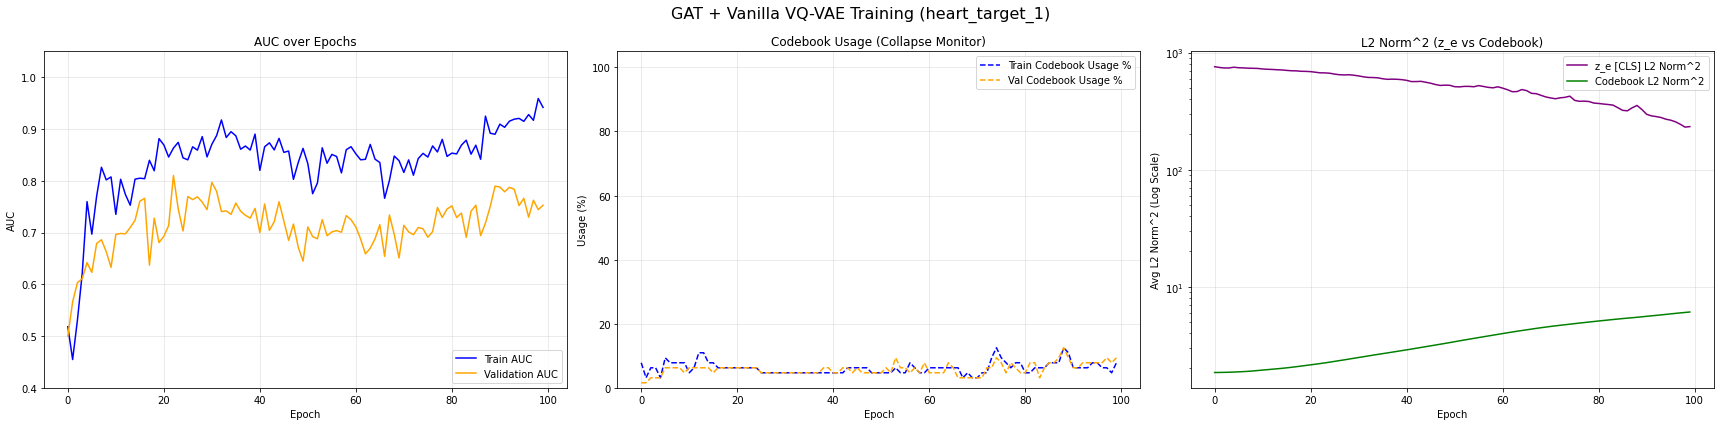

2025-11-17 13:08:21,322 - INFO - Visualizing final embedding space (using all [CLS] tokens)...


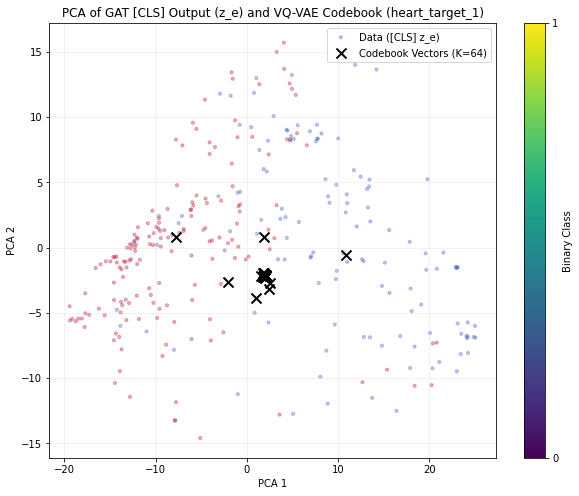

In [143]:
#
# ❗️ (블럭 5) 덮어쓰기
#
# --- 1. 훈련 곡선 시각화 (❗️ 1x3 그리드로 변경) ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6)) # ❗️ (1x3)
epochs = history['epoch']

# (a) AUC
ax1.plot(epochs, history['train_auc'], label='Train AUC', color='blue')
ax1.plot(epochs, history['val_auc'], label='Validation AUC', color='orange')
ax1.set_title("AUC over Epochs")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("AUC")
ax1.set_ylim(0.4, 1.05) 
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)

# (b) 코드북 붕괴(Collapse)
ax2.plot(epochs, history['train_usage'], label='Train Codebook Usage %', color='blue', linestyle='--')
ax2.plot(epochs, history['val_usage'], label='Val Codebook Usage %', color='orange', linestyle='--')
ax2.set_title("Codebook Usage (Collapse Monitor)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Usage (%)")
ax2.set_ylim(0, 105)
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- [ ❗️ (c) 신규: L2 Norm^2 스케일 플롯 ❗️ ] ---
ax3.plot(epochs, history['z_e_l2'], label='z_e [CLS] L2 Norm^2', color='purple')
ax3.plot(epochs, history['fy_l2'], label='Codebook L2 Norm^2', color='green')
ax3.set_title("L2 Norm^2 (z_e vs Codebook)")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Avg L2 Norm^2 (Log Scale)")
ax3.set_yscale('log') # ❗️ (로그 스케일)
ax3.legend()
ax3.grid(True, alpha=0.3)
# --- [ 신규 플롯 끝 ] ---

plt.suptitle(f"GAT + Vanilla VQ-VAE Training ({DATASET_NAME})", fontsize=16)
plt.tight_layout()
plt.show()


# --- 2. PCA 임베딩 공간 (클러스터링) 시각화 ---
logger.info("Visualizing final embedding space (using all [CLS] tokens)...")

# (a) 전체 [CLS] 토큰과 VQ 코드북 가져오기 (전체 데이터셋)
all_z_e = []
all_y = []
gat_encoder.eval() 
with torch.no_grad():
    for loader in [train_loader, val_loader, test_loader]:
        for batch in loader:
            bd = {k: (v.to(device) if isinstance(v, torch.Tensor) else v)
                  for k, v in batch.items()}
            
            z_e_cls = gat_encoder(bd) 
            
            all_z_e.append(z_e_cls.cpu().numpy())
            all_y.append(batch['y'].cpu().numpy())

Z_e_np = np.concatenate(all_z_e, axis=0) 
y_np = np.concatenate(all_y, axis=0) 
codebook_vectors_np = vq_quantizer.codebook.weight.detach().cpu().numpy()

# (b) PCA (인코더 출력 z_e 기준)
pca = PCA(n_components=2)
Z_e_2d = pca.fit_transform(Z_e_np) 
codebook_2d = pca.transform(codebook_vectors_np)

# (c) 플로팅 (데이터와 코드북 클러스터링)
plt.figure(figsize=(10, 8))
plt.scatter(Z_e_2d[:, 0], Z_e_2d[:, 1], c=y_np, cmap='coolwarm', alpha=0.3, s=10, label='Data ([CLS] z_e)')
plt.scatter(codebook_2d[:, 0], codebook_2d[:, 1], 
            marker='x', s=100, color='black', linewidth=2, 
            label=f'Codebook Vectors (K={K_CODES})')

plt.title(f"PCA of GAT [CLS] Output (z_e) and VQ-VAE Codebook ({DATASET_NAME})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.colorbar(ticks=[0, 1], label="Binary Class")
plt.grid(True, alpha=0.2)
plt.show()